# Synthetic pairs research: audited two-leg accounting

Quincy Jones | Review draft | October 3, 2026

Independent, AI-assisted research using synthetic prices. These are simulated outcomes, not personal trading results or evidence of live profitability. This version supersedes earlier drawdown claims.

Rolling 252-observation fits use only observations before each signal. Previous holdings earn the next mark-to-market P&L; closing trades then rebalance both legs, and every traded dollar incurs transaction costs. Returns use marked equity, with short borrow, funding exposure, and terminal liquidation.

Execution assumes fills at the observed close without latency. Cash earns no interest. Borrow availability, corporate actions, market impact and real market validation are excluded. Test next-period fills and real data before interpreting this as an executable strategy. The stress scenario and monitor are synthetic; the monitor is not an independently validated predictive risk model.

Run with Python 3 and numpy, pandas, matplotlib. Outputs are written to `pairs_trading_outputs/`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUT = Path.cwd() / 'pairs_trading_outputs'
OUT.mkdir(parents=True, exist_ok=True)
SEED, N, TRAIN, FIT_WINDOW, Z_WINDOW = 2609, 1200, 600, 252, 60
CAPITAL, GROSS, FEE, BORROW, FUNDING, MARGIN = 100000., 100000., .0005, .03, .06, .5
ENTRY, EXIT = 1.5, .35
rng = np.random.default_rng(SEED)
common = np.cumsum(rng.normal(0, .006, N))
spread = np.zeros(N)
for t in range(1, N):
    spread[t] = .92 * spread[t-1] + rng.normal(0, .008)
log_b = 4.5 + common
log_a = .25 + 1.15 * log_b + spread
stress_spread = spread.copy()
rng_stress = np.random.default_rng(SEED + 1)
for i, t in enumerate(range(TRAIN, N)):
    stress_spread[t] = np.linspace(.92, 1.02, N-TRAIN)[i] * stress_spread[t-1] + rng_stress.normal(0, .008)
stress_log_a = .25 + 1.15 * log_b + stress_spread

def fit(y, x):
    X = np.column_stack([np.ones(len(x)), x])
    return np.linalg.lstsq(X, y, rcond=None)[0]

def backtest(a, b, monitor=False, fee=FEE, borrow=BORROW, funding=FUNDING):
    """Trade at each close using that close and a fit ending at the previous close.
    Mark prior shares to current prices before placing new trades. Fixed gross
    dollars are rebalanced daily. Full liquidation occurs at the final close.
    """
    pa, pb = np.exp(a), np.exp(b)
    qa = qb = 0.
    equity = cash = CAPITAL
    side = confirmations = 0
    rows = []
    for t in range(TRAIN, len(a)):
        old_equity, old_cash = equity, cash
        long_before = max(qa*pa[t-1], 0) + max(qb*pb[t-1], 0)
        short_before = max(-qa*pa[t-1], 0) + max(-qb*pb[t-1], 0)
        pnl_a, pnl_b = qa*(pa[t]-pa[t-1]), qb*(pb[t]-pb[t-1])
        borrow_cost = short_before * borrow/252
        funded = max(0., long_before + MARGIN*short_before - old_equity)
        funding_cost = funded * funding/252
        alpha, beta = fit(a[t-FIT_WINDOW:t], b[t-FIT_WINDOW:t])
        history = a[t-FIT_WINDOW:t] - alpha - beta*b[t-FIT_WINDOW:t]
        sd = history[-Z_WINDOW:].std(ddof=1)
        z = (a[t]-alpha-beta*b[t]-history[-Z_WINDOW:].mean())/sd if sd > 1e-12 else 0.
        ar_alpha, phi = fit(history[-119:], history[-120:-1])
        confirmations = confirmations+1 if phi >= 1 else 0
        paused = monitor and confirmations >= 3
        if paused or equity <= 0:
            side = 0
        elif side == 0 and abs(z) >= ENTRY:
            side = -int(np.sign(z))
        elif side != 0 and abs(z) <= EXIT:
            side = 0
        if t == len(a)-1:
            side = 0
        new_qa = side*GROSS/(1+abs(beta))/pa[t]
        new_qb = -side*beta*GROSS/(1+abs(beta))/pb[t]
        delta_a, delta_b = new_qa-qa, new_qb-qb
        turnover = abs(delta_a)*pa[t] + abs(delta_b)*pb[t]
        transaction = turnover*fee
        cash = old_cash - delta_a*pa[t] - delta_b*pb[t] - transaction - borrow_cost - funding_cost
        equity = cash + new_qa*pa[t] + new_qb*pb[t]
        rows.append(dict(observation=t, price_a=pa[t], price_b=pb[t], fit_first=t-FIT_WINDOW,
            fit_last=t-1, alpha=alpha, beta=beta, z=z, ar_phi=phi, paused=paused,
            held_a=qa, held_b=qb, shares_a=new_qa, shares_b=new_qb,
            pnl_a=pnl_a, pnl_b=pnl_b, gross_pnl=pnl_a+pnl_b,
            turnover_usd=turnover, transaction_cost=transaction, borrow_cost=borrow_cost,
            funding_notional=funded, funding_cost=funding_cost,
            net_pnl=pnl_a+pnl_b-transaction-borrow_cost-funding_cost,
            cash=cash, equity=equity, daily_return=(equity-old_equity)/old_equity))
        qa, qb = new_qa, new_qb
    return pd.DataFrame(rows)

def metrics(df):
    equity = np.r_[CAPITAL, df.equity.to_numpy()]
    ret = df.daily_return.to_numpy()
    return dict(net_pnl_usd=float(df.net_pnl.sum()), ending_equity_usd=float(equity[-1]),
        total_return_pct=float((equity[-1]/CAPITAL-1)*100),
        max_drawdown_pct=float((equity/np.maximum.accumulate(equity)-1).min()*100),
        annualized_sharpe=float(ret.mean()/ret.std(ddof=1)*np.sqrt(252)) if ret.std(ddof=1)>0 else None,
        transaction_cost_usd=float(df.transaction_cost.sum()), borrow_cost_usd=float(df.borrow_cost.sum()),
        funding_cost_usd=float(df.funding_cost.sum()), observations=len(df))

paths = {'base': (log_a, log_b, False), 'stress': (stress_log_a, log_b, False),
         'stress_monitor': (stress_log_a, log_b, True)}
results = {name: backtest(*args) for name, args in paths.items()}
checks = []
def check(condition, name):
    assert bool(condition), name
    checks.append(name)
for name, df in results.items():
    check(np.allclose(df.gross_pnl, df.pnl_a+df.pnl_b, atol=1e-8), name+': two-leg dollar P&L')
    check(np.allclose(np.diff(np.r_[CAPITAL, df.equity]), df.net_pnl, atol=1e-8), name+': equity roll-forward')
    check(np.allclose(df.equity, df.cash+df.shares_a*df.price_a+df.shares_b*df.price_b, atol=1e-8), name+': cash and holdings ledger')
    check((df.fit_last < df.observation).all(), name+': training cutoff precedes signal')
    check(df.iloc[-1].shares_a == df.iloc[-1].shares_b == 0, name+': terminal liquidation')
    check(np.allclose(df.transaction_cost, df.turnover_usd*FEE, atol=1e-8), name+': costs on actual dollar turnover')
    check(np.allclose(np.cumprod(1+df.daily_return)*CAPITAL, df.equity, atol=1e-7), name+': returns use marked equity')
    df.to_csv(OUT / f'pairs_{name}_ledger.csv', index=False)
cut=950
mut = stress_log_a.copy()
mut[cut+1:] += np.linspace(0, .2, len(mut)-cut-1)
mut_df=backtest(mut, log_b, True)
original=results['stress_monitor']
check(np.allclose(mut_df.loc[mut_df.observation<=cut].select_dtypes('number'), original.loc[original.observation<=cut].select_dtypes('number'), atol=1e-8), 'future price mutation leaves earlier fits, holdings and P&L unchanged')
flat=backtest(np.full(N,4.5), np.full(N,4.5))
check(np.allclose(flat.equity,CAPITAL), 'flat prices and zero signals preserve capital')
no_cost=backtest(log_a,log_b,fee=0,borrow=0,funding=0)
check(no_cost.transaction_cost.sum()==no_cost.borrow_cost.sum()==no_cost.funding_cost.sum()==0, 'zero rates are valid zeros')
saved_gross=GROSS
GROSS=200000.
funded_test=backtest(log_a,log_b)
GROSS=saved_gross
check(funded_test.funding_cost.sum()>0, 'higher gross exposure triggers financing cost')
check(np.allclose(funded_test.funding_cost, funded_test.funding_notional*FUNDING/252), 'funding charge uses positive financing exposure')
# Recompute selected fits and dollar trades using scalar arithmetic outside the ledger build.
for i in [0,100,350,len(original)-1]:
    row=original.iloc[i]; t=int(row.observation)
    aa,bb=fit(stress_log_a[t-252:t],log_b[t-252:t])
    check(abs(row.beta-bb)<1e-10 and abs(row.alpha-aa)<1e-10, f'rolling fit sample {t}')
    independent=float(row.held_a)*(np.exp(stress_log_a[t])-np.exp(stress_log_a[t-1]))+float(row.held_b)*(np.exp(log_b[t])-np.exp(log_b[t-1]))
    check(abs(independent-row.gross_pnl)<1e-8, f'held-share mark-to-market sample {t}')
summary={name:metrics(df) for name,df in results.items()}
(OUT/'pairs_metrics.json').write_text(json.dumps(summary,indent=2))
(OUT/'pairs_audit.json').write_text(json.dumps({'checks':checks,'passed':len(checks),'failed':0},indent=2))
fig, axes=plt.subplots(1,2,figsize=(12,4.5))
for name,df in results.items():
    axes[0].plot(df.observation,df.equity,label=name.replace('_',' '))
    e=np.r_[CAPITAL,df.equity]; axes[1].plot(np.r_[TRAIN-1,df.observation],(e/np.maximum.accumulate(e)-1)*100,label=name.replace('_',' '))
axes[0].set(title='Synthetic two-leg equity after costs',ylabel='USD',xlabel='Observation')
axes[1].set(title='Drawdown from marked equity',ylabel='Percent',xlabel='Observation')
for ax in axes: ax.grid(alpha=.2); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT/'pairs_equity.png',dpi=160)
print(json.dumps({'metrics':summary,'audit_checks':len(checks)},indent=2))


{
  "metrics": {
    "base": {
      "net_pnl_usd": 12223.659995536618,
      "ending_equity_usd": 112223.65999553674,
      "total_return_pct": 12.223659995536739,
      "max_drawdown_pct": -2.6155622321498373,
      "annualized_sharpe": 1.3624758618839263,
      "transaction_cost_usd": 1873.8632524256595,
      "borrow_cost_usd": 1488.68844999262,
      "funding_cost_usd": 0.0,
      "observations": 600
    },
    "stress": {
      "net_pnl_usd": -2060.7583114529743,
      "ending_equity_usd": 97939.24168854707,
      "total_return_pct": -2.060758311452926,
      "max_drawdown_pct": -9.89466250717741,
      "annualized_sharpe": -0.1658029238677537,
      "transaction_cost_usd": 2130.4341848650956,
      "borrow_cost_usd": 2598.4475878827375,
      "funding_cost_usd": 0.0,
      "observations": 600
    },
    "stress_monitor": {
      "net_pnl_usd": -268.6303207371284,
      "ending_equity_usd": 99731.3696792629,
      "total_return_pct": -0.2686303207370955,
      "max_drawdown_pct":

## Executed equity and drawdown comparison
Generated by the code above; includes modeled costs.


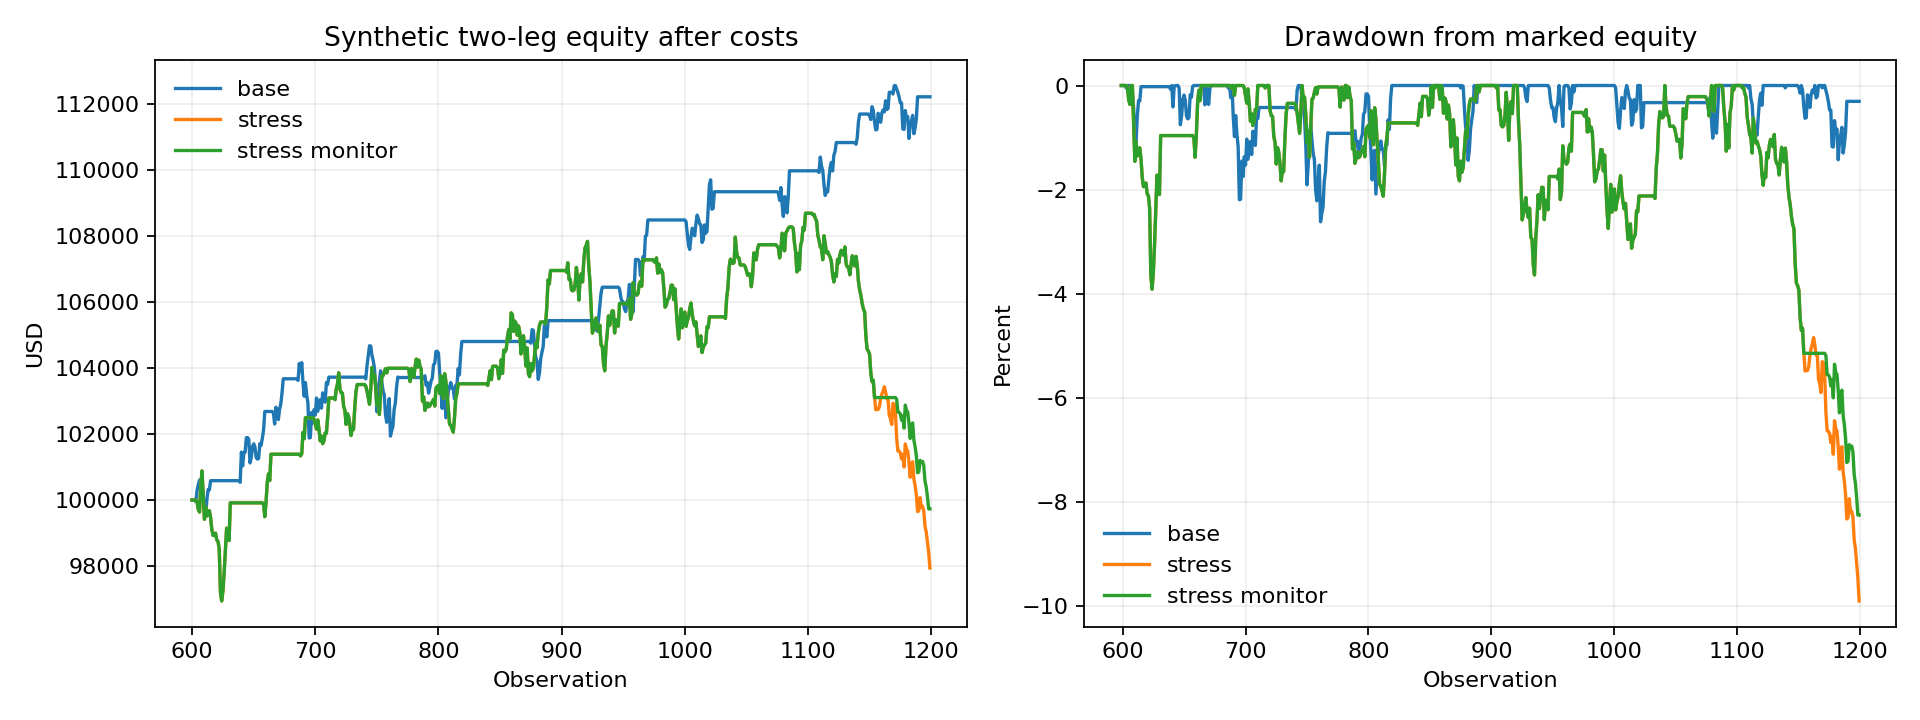